# Assignment VOL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('/home/jlaw/projects/python/roboAdvisorSystTrading/notebooks/data/assignment_VOL_data.xlsx')
pd.set_option('display.max_columns', None) # Show all columns when printing a dataframe
df.head()

,Date,Close,daily % chg,20day vol,previous 20d return,next 20 day return,zvol20,zfret20,zret20
0,1960-01-04,59.910000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1960-01-05,60.389999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1960-01-06,60.130001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1960-01-07,59.689999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1960-01-08,59.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Part A: Setup Data and Indicators

### Step 1: Calculate Daily Returns and 20-day Volatility

In [3]:
dfvol = df[['Date','Close']]

# Assign a new index starting from 1
dfvol.index = np.arange(1, len(dfvol) + 1)

#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

# Compute daily returns
dfvol['dailyPct'] = dfvol['Close'].pct_change()

# Compute 20 day volatility (standard deviation of daily returns)
dfvol['vol20'] = dfvol['dailyPct'].rolling(window=20).std()

# Compute previous 20 day return (cumulative return over the past 20 days)
dfvol['ret20'] = dfvol['dailyPct'].rolling(window=20).apply(lambda x: np.prod(1 + x) - 1)

# Compute future 20 day return (cumulative return over the next 20 days)
dfvol['fret20'] = (1 + dfvol['dailyPct']).rolling(window=20).apply(np.prod, raw=True).shift(-19) - 1

### Step 2: Calculate Z-Scores (Normalized Volatility and Returns)

Using a 250-day rolling window for mean and standard deviation

In [4]:
# Normalize vol20 to get zvol20 (backward-looking 250-day window)
dfvol['zvol20'] = (dfvol['vol20'] - dfvol['vol20'].rolling(window=250).mean()) / dfvol['vol20'].rolling(window=250).std()

# Normalize ret20 to get zret20 (backward-looking 250-day window)
dfvol['zret20'] = (dfvol['ret20'] - dfvol['ret20'].rolling(window=250).mean()) / dfvol['ret20'].rolling(window=250).std()

# Normalize fret20 to get zfret20 (backward-looking 250-day window)
dfvol['zfret20'] = (dfvol['fret20'] - dfvol['fret20'].rolling(window=250).mean()) / dfvol['fret20'].rolling(window=250).std()

### Step 3: Prepare Clean Dataset for Analysis

Remove rows with missing data and create quintile buckets

In [5]:
# Remove rows with NaN values (due to rolling calculations)
dfvol.dropna(inplace=True)

# Sort by zvol20 and assign quintiles
dfvol = dfvol.sort_values(by='zvol20').reset_index(drop=True)
dfvol['vol_quintile'] = pd.qcut(dfvol.index, q=5, labels=False) + 1  # Quintiles labeled 1 to 5

## Part A: Analysis Questions

### Question 1: Concurrent Relationship between zvol20 and zret20

Is there a concurrent relationship between normalized volatility and normalized returns?

   vol_quintile    zvol20    zret20
0             1 -1.247964  0.139109
1             2 -0.661993  0.076730
2             3 -0.197532  0.053891
3             4  0.448101 -0.060286
4             5  2.030323 -0.439100


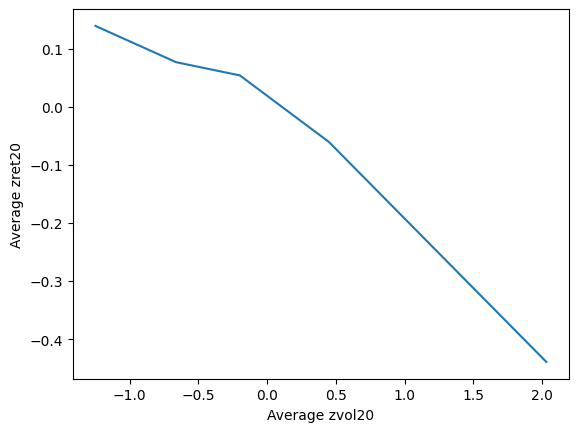

In [6]:
# Group by vol_quintile and calculate average zvol20 and zret20 for each quintile
quintile_stats = dfvol.groupby('vol_quintile').agg({'zvol20': 'mean', 'zret20': 'mean'}).reset_index()
print(quintile_stats)

# Plot relationship between average zvol20 and average zret20 for each quintile
plt.plot(quintile_stats['zvol20'], quintile_stats['zret20'])
plt.xlabel('Average zvol20')
plt.ylabel('Average zret20')
plt.show()

### Question 2: Lead-Lag Relationship between zvol20 and zfret20

Is there a lead-lag relationship between normalized volatility and FUTURE normalized returns?

   vol_quintile    zvol20   zfret20
0             1 -1.247964 -0.159718
1             2 -0.661993 -0.111113
2             3 -0.197532 -0.054110
3             4  0.448101 -0.001711
4             5  2.030323  0.080579


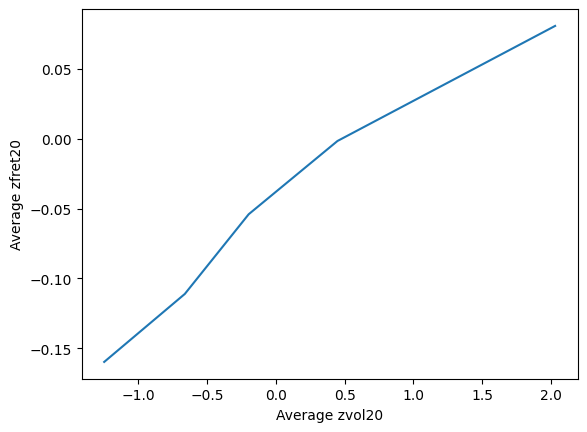

In [7]:
# Group by vol_quintile and calculate average zvol20 and zfret20 for each quintile
quintile_stats = dfvol.groupby('vol_quintile').agg({'zvol20': 'mean', 'zfret20': 'mean'}).reset_index()
print(quintile_stats)

# Plot relationship between average zvol20 and average zfret20 for each quintile
plt.plot(quintile_stats['zvol20'], quintile_stats['zfret20'])
plt.xlabel('Average zvol20')
plt.ylabel('Average zfret20')
plt.show()

In [8]:
# Correlation between zvol20 and zret20
correlation = dfvol['zvol20'].corr(dfvol['zret20'])
print(f'Correlation between zvol20 and zret20: {correlation}')

# Correlation between zvol20 and zfret20
correlation = dfvol['zvol20'].corr(dfvol['zfret20'])
print(f'Correlation between zvol20 and zfret20: {correlation}')


Correlation between zvol20 and zret20: -0.23298487103302756
Correlation between zvol20 and zfret20: 0.07283182443693567


### There is a negative correlation between returns and volatility
#### Higher volatility drags down returns

### There is little-to-no correlation between future returns and volatility
#### Cannot use volatility to predict future returns

### Thoughts:
#### Classic -5% off 100 is 95, but +5% on 95 is only 99.75 example (volatility drag). Shows that volatility hurts returns.
#### Presumably all volatility information is priced into today's prices, so knowing volatility can't help you find an edge.

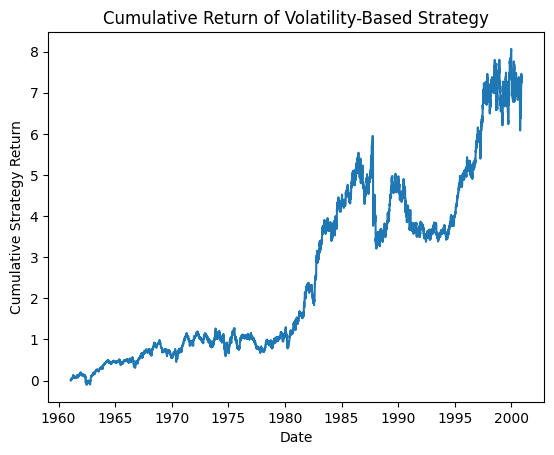

In [34]:
#sort dfvol by Date
dfvol = dfvol.sort_values('Date')
# Take 1x daily return when zvol20 is less than -.5 stdev or greater than .5 stdev, otherwise -1x return - in a new column called 'strategy_return'
dfvol['strategy_return'] = np.where((dfvol['zvol20'] < 0.) | (dfvol['zvol20'] > 0.5), dfvol['dailyPct'], -dfvol['dailyPct'])
# Calculate cumulative return of the strategy
dfvol['cumulative_strategy_return'] = (1 + dfvol['strategy_return']).cumprod() - 1
# visualize the cumulative return of the strategy over time
plt.plot(dfvol['Date'], dfvol['cumulative_strategy_return'])
plt.xlabel('Date')
plt.ylabel('Cumulative Strategy Return')
plt.title('Cumulative Return of Volatility-Based Strategy')
plt.show()

In [35]:
# sharpe ratio of the strategy
sharpe_ratio = ((dfvol['strategy_return'].mean() - (.037 / 252)) / dfvol['strategy_return'].std()) * np.sqrt(252)  # Annualize the Sharpe ratio
print(f'Sharpe Ratio of the strategy: {sharpe_ratio}')

Sharpe Ratio of the strategy: 0.183752960476283


In [36]:
dfvol.head(100)

,Date,Close,dailyPct,vol20,ret20,fret20,zvol20,zret20,zfret20,vol_quintile,strategy_return,cumulative_strategy_return
836,1961-01-26,60.619999,0.001487,0.004319,0.049152,0.034033,-1.221705,1.346927,0.737634,1,0.001487,0.001487
1479,1961-01-27,61.240002,0.010228,0.004639,0.054953,0.036622,-1.013366,1.504700,0.809438,1,0.010228,0.011730
2637,1961-01-30,61.970001,0.011920,0.005055,0.066426,0.033638,-0.745520,1.820748,0.717342,2,0.011920,0.023790
1031,1961-01-31,61.779999,-0.003066,0.004391,0.073128,0.023721,-1.154954,1.997130,0.421731,1,-0.003066,0.020651
324,1961-02-01,61.900002,0.001942,0.003688,0.060658,0.026708,-1.582081,1.625601,0.504013,1,0.001942,0.022633
...,...,...,...,...,...,...,...,...,...,...,...,...
6607,1961-06-14,65.980003,0.002736,0.007092,-0.012719,-0.007295,0.260489,-0.820750,-0.557863,4,-0.002736,0.064310
6554,1961-06-15,65.690002,-0.004395,0.007062,-0.020722,-0.016975,0.243967,-1.061190,-0.852150,4,0.004395,0.068988
6567,1961-06-16,65.180000,-0.007764,0.007084,-0.032794,-0.006241,0.248462,-1.423310,-0.530836,4,0.007764,0.077288
6720,1961-06-19,64.580002,-0.009205,0.007225,-0.035975,-0.005983,0.301438,-1.507666,-0.527357,4,0.009205,0.087204
